In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pyvista as pv
import xml.etree.ElementTree as ET
from xml.dom import minidom
from pathlib import Path
import open3d as o3d
import warnings
from shapely.geometry import Polygon, Point, box, LineString
from shapely.ops import unary_union
from shapely import affinity
import shutil
import pandas as pd
import json
import mitsuba as mi
from tqdm import tqdm
import gc

# ============================ 1. dataset parameters ============================
NUM_CITIES = 31
TRAJS_PER_CITY = 500 
SEED_BASE = 6666
MAX_BUILDING_H = 60.0

DT = 0.1
NUM_FRAMES = 20
CAM_FOV = 90.0
IMG_RES = (512, 512)
BS_POS = [0.0, 0.0, 65.0]
CITY_CENTER_X, CITY_CENTER_Y = 75.0, 0.0


ITU_MATS = ["marble", "concrete", "metal", "medium_dry_ground", "wood", "glass"]

try:
    mi.set_variant("scalar_rgb") 
except:
    pass 
mi.set_log_level(mi.LogLevel.Error)
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)

OUTPUT_DIR = Path("Dataset/OSM_Train_AllModes").resolve()
warnings.filterwarnings("ignore")

# ============================ 2. cell generator============================
class DiverseCityGenerator:
    def __init__(self, width, length, offset_x, offset_y):
        self.width, self.length = width, length
        self.offset_x, self.offset_y = offset_x, offset_y
        base_poly = Polygon([(-width/2, -length/2), (width/2, -length/2), (width/2, length/2), (-width/2, length/2)])
        self.ground_poly = affinity.translate(base_poly, xoff=offset_x, yoff=offset_y)
        
    def generate_random_layout(self, rng):
        street_w, block_w = rng.uniform(8, 16), rng.uniform(15, 35)
        density = rng.uniform(0.7, 0.9) 
        roads, buildings = [], []
        
        step = block_w + street_w
        cols = int(self.width / step)
        rows = int(self.length / step)
        sx = - (cols * step - street_w) / 2
        sy = - (rows * step - street_w) / 2
        
        # 1. roads
        for c in range(cols - 1):
            rx = sx + (c + 1) * block_w + c * street_w
            r_poly = box(rx, -self.length/2, rx + street_w, self.length/2)
            roads.append(affinity.translate(r_poly, xoff=self.offset_x, yoff=self.offset_y))
        for r in range(rows - 1):
            ry = sy + (r + 1) * block_w + r * street_w
            r_poly = box(-self.width/2, ry, self.width/2, ry + street_w)
            roads.append(affinity.translate(r_poly, xoff=self.offset_x, yoff=self.offset_y))

        if len(roads) == 0:
            roads.append(affinity.translate(box(-5, -self.length/2, 5, self.length/2), xoff=self.offset_x, yoff=self.offset_y))
            roads.append(affinity.translate(box(-self.width/2, -5, self.width/2, 5), xoff=self.offset_x, yoff=self.offset_y))

        # 2. buildings
        for c in range(cols):
            for r in range(rows):
                cx, cy = sx + c * step, sy + r * step
                if rng.random() < density:
                    b_rect = box(cx+2, cy+2, cx+block_w-2, cy+block_w-2)
                    b_rect = affinity.rotate(b_rect, rng.uniform(-5, 5))
                    h = rng.uniform(20, MAX_BUILDING_H)
                    buildings.append({"poly": affinity.translate(b_rect, xoff=self.offset_x, yoff=self.offset_y), "height": h})
        
        while len(buildings) < 2:
            current_count = len(buildings)
            h = rng.uniform(20, MAX_BUILDING_H)
            
            if current_count == 0:
                b_rect = box(-20, -10, -5, 10)
            else:
                b_rect = box(5, -10, 20, 10)

            buildings.append({"poly": affinity.translate(b_rect, xoff=self.offset_x, yoff=self.offset_y), "height": h})

        return roads, buildings

# ============================ 3. 核心工具 ============================
def clean_ply_for_mitsuba(ply_path):
    try:
        mesh = o3d.io.read_triangle_mesh(str(ply_path))
        o3d.io.write_triangle_mesh(str(ply_path), mesh, write_ascii=True) 
    except: pass

def make_scene_xml_base():
    scene = ET.Element("scene", version="2.1.0")
    ET.SubElement(scene, "default", name="spp", value="64")
    ET.SubElement(scene, "integrator", type="path")
    ET.SubElement(scene, "emitter", type="constant", id="World")
    for mat in ITU_MATS:
        bsdf = ET.SubElement(scene, "bsdf", type="itu-radio-material", id=f"mat-itu_{mat}")
        ET.SubElement(bsdf, "string", name="material_type", value=mat)
    return scene

def xml_add_shape(scene_xml_root, rel_path, mat_id, shape_id):
    s = ET.SubElement(scene_xml_root, "shape", type="ply", id=shape_id)
    path_str = str(rel_path).replace("\\", "/")
    ET.SubElement(s, "string", name="filename", value=path_str)
    ET.SubElement(s, "ref", id=mat_id, name="bsdf")
    return s

def xml_add_fixed_bs_camera(scene_xml_root, bs_pos, look_at_target, resx=640, resy=480, fov=60):
    sensor = ET.SubElement(scene_xml_root, "sensor", type="perspective", id="bs_camera")
    ET.SubElement(sensor, "float", name="fov", value=str(fov))
    transform = ET.SubElement(sensor, "transform", name="to_world")
    ET.SubElement(transform, "lookat", 
                  origin=f"{bs_pos[0]},{bs_pos[1]},{bs_pos[2]}",
                  target=f"{look_at_target[0]},{look_at_target[1]},{look_at_target[2]}", 
                  up="0,0,1")
    sampler = ET.SubElement(sensor, "sampler", type="independent")
    ET.SubElement(sampler, "integer", name="sample_count", value="64")
    film = ET.SubElement(sensor, "film", type="hdrfilm")
    ET.SubElement(film, "integer", name="width", value=str(resx))
    ET.SubElement(film, "integer", name="height", value=str(resy))
    ET.SubElement(film, "string", name="pixel_format", value="rgb")
    ET.SubElement(film, "string", name="component_format", value="float32") 
    ET.SubElement(film, "boolean", name="banner", value="false")
    return sensor

def simulate_bs_lidar_scan_optimized(static_meshes_combined, dynamic_mesh_path, bs_pos, num_points=10000): 
    uav_mesh = o3d.io.read_triangle_mesh(str(dynamic_mesh_path))
    combined = static_meshes_combined + uav_mesh
    scene = o3d.t.geometry.RaycastingScene()
    scene.add_triangles(o3d.t.geometry.TriangleMesh.from_legacy(combined))
    dirs = np.random.normal(size=(int(num_points*1.2), 3))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    rays = np.concatenate([np.repeat(np.array(bs_pos).reshape(1,3), len(dirs), axis=0), dirs], axis=1).astype(np.float32)
    ans = scene.cast_rays(o3d.core.Tensor(rays))
    t_hit = ans['t_hit'].numpy()
    mask = np.isfinite(t_hit)
    pts = rays[mask, :3] + dirs[mask] * t_hit[mask][:,None]
    if pts.shape[0] > 0:
        idx = np.random.choice(pts.shape[0], min(num_points, pts.shape[0]), replace=False)
        return o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts[idx]))
    else:
        return o3d.geometry.PointCloud()

def make_visual_scene_xml(bs_pos, look_at, fov, res=(1280, 960), spp=64):
    scene = ET.Element("scene", version="2.1.0")
    ET.SubElement(scene, "integrator", type="direct")
    emitter = ET.SubElement(scene, "emitter", type="constant")
    ET.SubElement(emitter, "rgb", name="radiance", value="1.0, 1.0, 1.0")
    sensor = ET.SubElement(scene, "sensor", type="perspective")
    ET.SubElement(sensor, "float", name="fov", value=str(fov))
    tf = ET.SubElement(sensor, "transform", name="to_world")
    ET.SubElement(tf, "lookat", origin=f"{bs_pos[0]}, {bs_pos[1]}, {bs_pos[2]}", target=f"{look_at[0]}, {look_at[1]}, {look_at[2]}", up="0, 0, 1")
    sampler = ET.SubElement(sensor, "sampler", type="independent")
    ET.SubElement(sampler, "integer", name="sample_count", value=str(spp))
    film = ET.SubElement(sensor, "film", type="hdrfilm")
    ET.SubElement(film, "integer", name="width", value=str(res[0]))
    ET.SubElement(film, "integer", name="height", value=str(res[1]))
    ET.SubElement(film, "string", name="pixel_format", value="rgb")
    ET.SubElement(film, "string", name="component_format", value="float32")
    ET.SubElement(film, "rfilter", type="tent")
    return scene

def add_visual_materials(scene_root):
    m = ET.SubElement(scene_root, "bsdf", type="diffuse", id="mat_ground")
    ET.SubElement(m, "rgb", name="reflectance", value="0.75, 0.75, 0.72")
    m = ET.SubElement(scene_root, "bsdf", type="diffuse", id="mat_road")
    ET.SubElement(m, "rgb", name="reflectance", value="0.35, 0.35, 0.36")
    m = ET.SubElement(scene_root, "bsdf", type="diffuse", id="mat_building")
    ET.SubElement(m, "rgb", name="reflectance", value="0.80, 0.76, 0.68")
    m = ET.SubElement(scene_root, "bsdf", type="diffuse", id="mat_roof")
    ET.SubElement(m, "rgb", name="reflectance", value="0.62, 0.64, 0.70")
    m = ET.SubElement(scene_root, "bsdf", type="plastic", id="mat_uav")
    ET.SubElement(m, "rgb", name="diffuse_reflectance", value="0.75, 0.10, 0.10")

def xml_add_vis_shape(scene_root, rel_path, mat_id, translate_xyz=None):
    s = ET.SubElement(scene_root, "shape", type="ply")
    ET.SubElement(s, "string", name="filename", value=str(rel_path).replace("\\", "/"))
    if translate_xyz:
        tf = ET.SubElement(s, "transform", name="to_world")
        ET.SubElement(tf, "translate", value=f"{translate_xyz[0]}, {translate_xyz[1]}, {translate_xyz[2]}")
    ET.SubElement(s, "ref", id=mat_id)

def render_with_mitsuba(time_dir, xml_name="scene_vis.xml", out_png="bs_rgb.png"):
    try:
        scene = mi.load_file(str(time_dir / xml_name))
        img = mi.render(scene)
        mi.util.write_bitmap(str(time_dir / out_png), img)
        del scene
        return True
    except Exception as e:
        print(f"Render Error: {e}")
        return False

# ============================ 4. kinematics ============================
class KinematicPlanner:
    def __init__(self, roads, buildings, rng, bs_pos):
        self.roads = roads
        self.buildings = buildings
        self.rng = rng
        self.bs_pos = np.array(bs_pos)
        
        self.collider_zone = unary_union([b["poly"].buffer(0.5) for b in buildings])
        self.road_zone = unary_union(roads).buffer(0.0) 
        

        all_geoms = roads + [b['poly'] for b in buildings]
        if not all_geoms: 
            min_x, min_y, max_x, max_y = -50, -50, 50, 50
        else:
            min_x = min(g.bounds[0] for g in all_geoms)
            min_y = min(g.bounds[1] for g in all_geoms)
            max_x = max(g.bounds[2] for g in all_geoms)
            max_y = max(g.bounds[3] for g in all_geoms)
        
        self.safe_x_min = min_x + 2.0
        self.safe_y_min = min_y + 2.0
        self.safe_x_max = max_x - 2.0
        self.safe_y_max = max_y - 2.0
        
        self.map_bounds = (min_x, min_y, max_x, max_y)

    def _clamp_pos(self, x, y):
        x = np.clip(x, self.safe_x_min, self.safe_x_max)
        y = np.clip(y, self.safe_y_min, self.safe_y_max)
        return x, y

    def _is_valid_point(self, p_2d, check_road=True):
        if not (self.safe_x_min <= p_2d[0] <= self.safe_x_max and 
                self.safe_y_min <= p_2d[1] <= self.safe_y_max):
            return False
            
        pt = Point(p_2d[0], p_2d[1])
        not_hit_building = not self.collider_zone.contains(pt)
        if check_road:
            return self.road_zone.contains(pt) and not_hit_building
        else:
            return not_hit_building

    def _scan_surroundings(self, curr_pos, curr_dir):
        look_dist = 12.0  
        curr_angle = np.arctan2(curr_dir[1], curr_dir[0])
        scans = [
            {"type": "straight", "angle": curr_angle,          "vec": curr_dir},
            {"type": "left",     "angle": curr_angle + np.pi/2, "vec": None},
            {"type": "right",    "angle": curr_angle - np.pi/2, "vec": None}
        ]
        valid_options = []
        for item in scans:
            if item["vec"] is None:
                item["vec"] = np.array([np.cos(item["angle"]), np.sin(item["angle"])])
            check_p = curr_pos + item["vec"] * look_dist
            if self._is_valid_point(check_p, check_road=True):
                valid_options.append(item)
        return valid_options

    # --- 1. Orbit ---
    def _generate_orbit_path(self, num_frames):
        if not self.buildings: return None
        target_b = self.rng.choice(self.buildings)
        center = np.array([target_b['poly'].centroid.x, target_b['poly'].centroid.y])
        b_bounds = target_b['poly'].bounds
        
        base_radius = max(b_bounds[2]-b_bounds[0], b_bounds[3]-b_bounds[1]) / 2.0 + self.rng.uniform(10.0, 20.0)
        z = self.rng.uniform(30.0, 60.0)
        z_speed = self.rng.uniform(3.0, 6.0) * self.rng.choice([-1, 1])
        r_speed = self.rng.uniform(0.5, 1.5) * self.rng.choice([-1, 1])
        
        base_omega = 8.0 / base_radius 
        if self.rng.random() < 0.5: base_omega *= -1
        current_angle = self.rng.uniform(0, 2*np.pi)
        
        seq = []
        current_r = base_radius
        
        for k in range(num_frames):
            current_omega = base_omega * (1.0 + 0.2 * np.sin(k * 0.5))
            current_angle += current_omega * DT
            z += z_speed * DT 
            if z > 80: z = 80; z_speed *= -1
            if z < 10: z = 10; z_speed *= -1
            current_r += r_speed * DT
            current_r = max(current_r, 10.0)
            
            seq.append({
                'time': k*DT, 
                'x': center[0] + current_r * np.cos(current_angle), 
                'y': center[1] + current_r * np.sin(current_angle), 
                'z': z, 
                'mode': 'orbit'
            })
        return seq

    # --- 2. Scan ---
    def _generate_scan_path(self, num_frames):
        z = self.rng.uniform(50.0, 80.0)
        cx = self.rng.uniform(self.safe_x_min+20, self.safe_x_max-20)
        cy = self.rng.uniform(self.safe_y_min+20, self.safe_y_max-20)
        
        target_speed = 12.0
        current_speed = target_speed
        seq = []
        curr_x, curr_y = cx - 20, cy - 20
        direction = 1
        
        for k in range(num_frames):
            dist_to_edge = 30 - abs(curr_x - cx)
            if dist_to_edge < 5.0:
                current_speed = max(4.0, current_speed * 0.8)
            else:
                current_speed += (target_speed - current_speed) * 0.2
            
            curr_x += direction * current_speed * DT
            if abs(curr_x - cx) > 30:
                direction *= -1
                curr_y += 4.0 
                z += self.rng.choice([-2.0, 2.0])
            z += 0.5 * np.sin(k * 0.5) * DT 
            
            seq.append({'time': k*DT, 'x': curr_x, 'y': curr_y, 'z': z, 'mode': 'scan'})
        return seq

    # --- 3. Hover ---
    def _generate_hover_path(self, num_frames):
        for _ in range(10):
            tx, ty = self.rng.uniform(self.safe_x_min, self.safe_x_max), self.rng.uniform(self.safe_y_min, self.safe_y_max)
            if self._is_valid_point([tx, ty], check_road=False):
                z = self.rng.uniform(10, 50)
                drift_v = self.rng.normal(0, 0.5, 3)
                seq = []
                curr_p = np.array([tx, ty, z])
                for k in range(num_frames):
                    drift_v += self.rng.normal(0, 0.2, 3) * DT
                    drift_v -= drift_v * 0.1 * DT
                    curr_p += drift_v * DT
                    seq.append({'time': k*DT, 'x': curr_p[0], 'y': curr_p[1], 'z': curr_p[2], 'mode': 'hover'})
                return seq
        return None

    # --- 4 & 5. Linear ---
    def _generate_linear_path(self, num_frames, mode_name, h_min, h_max, v_min, v_max):
        for _ in range(10):
            sx, sy = self.rng.uniform(self.safe_x_min, self.safe_x_max), self.rng.uniform(self.safe_y_min, self.safe_y_max)
            if self._is_valid_point([sx, sy], check_road=False):
                z = self.rng.uniform(h_min, h_max)
                angle = self.rng.uniform(0, 2*np.pi)
                dir_vec = np.array([np.cos(angle), np.sin(angle)])
                current_v = self.rng.uniform(v_min, v_max)
                vz = self.rng.uniform(-1.5, 1.5)
                curr_p = np.array([sx, sy])
                seq = []
                for k in range(num_frames):
                    target_v = v_min + (v_max - v_min) * (0.5 + 0.5 * np.sin(k * 0.3))
                    current_v += (target_v - current_v) * 0.1 
                    curr_p += dir_vec * current_v * DT
                    z += vz * DT
                    z_noise = 2.0 * np.sin(k * 0.2)
                    final_z = np.clip(z + z_noise, h_min-5, h_max+5)
                    seq.append({'time': k*DT, 'x': curr_p[0], 'y': curr_p[1], 'z': final_z, 'mode': mode_name})
                return seq
        return None

    # --- 6. Inspect ---
    def _generate_inspect_path(self, num_frames):
        if not self.buildings: return None
        target_b = self.rng.choice(self.buildings)
        poly = target_b['poly']
        coords = list(poly.exterior.coords)
        if len(coords) < 2: return None
        idx = self.rng.integers(0, len(coords)-1)
        wall_center = (np.array(coords[idx]) + np.array(coords[idx+1])) / 2.0
        center = np.array([poly.centroid.x, poly.centroid.y])
        vec = wall_center - center; vec /= np.linalg.norm(vec)
        hover_xy = wall_center + vec * 3.0
        
        if not (self.safe_x_min <= hover_xy[0] <= self.safe_x_max and 
                self.safe_y_min <= hover_xy[1] <= self.safe_y_max):
            return None

        z_start = self.rng.uniform(5.0, target_b['height']-10)
        vz = self.rng.choice([3.0, -3.0])
        z = z_start
        seq = []
        for k in range(num_frames):
            current_vz = vz * (0.5 + 0.5 * np.cos(k * 0.5)) 
            z += current_vz * DT
            z = np.clip(z, 2.0, target_b['height'])
            x_jitter = self.rng.normal(0, 0.05)
            y_jitter = self.rng.normal(0, 0.05)
            seq.append({'time': k*DT, 'x': hover_xy[0]+x_jitter, 'y': hover_xy[1]+y_jitter, 'z': z, 'mode': 'inspect'})
        return seq

    # --- 7. Zigzag ---
    def _generate_zigzag_path(self, num_frames):
        for _ in range(10):
            sx = self.rng.uniform(self.safe_x_min + 5, self.safe_x_max - 5)
            sy = self.rng.uniform(self.safe_y_min + 5, self.safe_y_max - 5)
            
            if not self._is_valid_point([sx, sy], check_road=False):
                continue
                
            angle = self.rng.uniform(0, 2*np.pi)
            direction = np.array([np.cos(angle), np.sin(angle)]) 
            perp_dir = np.array([-direction[1], direction[0]])   
            
            z = self.rng.uniform(10.0, 30.0)
            curr_p = np.array([sx, sy])
            
            seq = []
            valid_path = True
            
            # 4. trajectory generator
            for k in range(num_frames):
                v_fwd = 5.0 + 1.0 * np.sin(k * 0.2)
                v_lat = 4.0 * np.cos(k * 0.8) 
                v_z = 1.5 * np.sin(k * 1.0)
                curr_p += (direction * v_fwd + perp_dir * v_lat) * DT
                z += v_z * DT
                if not self._is_valid_point(curr_p, check_road=False): 
                    valid_path = False
                    break
                
                curr_p[0], curr_p[1] = self._clamp_pos(curr_p[0], curr_p[1])
                z = np.clip(z, 5.0, 50.0)   
                seq.append({'time': k * DT, 'x': curr_p[0], 'y': curr_p[1], 'z': z, 'mode': 'Zigzag'})  
            if valid_path and len(seq) == num_frames:
                return seq
                
        return None

    # --- 8. Wall Hug ---
    def _generate_wall_hug_path(self, num_frames):
        if not self.buildings: return None
        
        for _ in range(20):
            target_b = self.rng.choice(self.buildings)
            
            b_bounds = target_b['poly'].bounds
            margin = 6.0 
            if (b_bounds[0] < self.safe_x_min + margin or b_bounds[1] < self.safe_y_min + margin or
                b_bounds[2] > self.safe_x_max - margin or b_bounds[3] > self.safe_y_max - margin):
                continue

            fly_poly = target_b['poly'].buffer(4.0, join_style=1) 
            if fly_poly.is_empty: continue
            
            fly_route = fly_poly.exterior
            total_length = fly_route.length 
            if total_length < 20.0: continue

            start_dist = self.rng.uniform(0, total_length)
            direction = 1 if self.rng.random() < 0.5 else -1
            z = self.rng.uniform(10.0, 20.0)
            z_climb_rate = self.rng.uniform(0.5, 1.5)
            base_speed = 6.0 
            curr_dist = start_dist
            
            seq = []
            
            for k in range(num_frames):
                current_speed = base_speed + 1.0 * np.sin(k * 0.1)
                curr_dist += current_speed * DT * direction
                curr_dist = curr_dist % total_length
                curr_pt = fly_route.interpolate(curr_dist)
                
                z += z_climb_rate * DT
                if z > target_b['height'] + 5: z_climb_rate *= -1
                if z < 5.0: z = 5.0; z_climb_rate *= -1
            
                sx, sy = self._clamp_pos(curr_pt.x, curr_pt.y)

                seq.append({
                    'time': k * DT, 
                    'x': sx, 'y': sy, 'z': z, 
                    'mode': 'wall_hug'
                })
            
            return seq 
        return None

    # --- 9 & 10. Street Patrol / Sudden Turn ---
    def generate_traj(self, mode):
        seq = None
        if mode == 'orbit': seq = self._generate_orbit_path(NUM_FRAMES)
        elif mode == 'scan': seq = self._generate_scan_path(NUM_FRAMES)
        elif mode == 'hover': seq = self._generate_hover_path(NUM_FRAMES)
        elif mode == 'city_cruise': seq = self._generate_linear_path(NUM_FRAMES, mode, 30, 60, 8, 15)
        elif mode == 'fast_transit': seq = self._generate_linear_path(NUM_FRAMES, mode, 50, 80, 15, 25)
        elif mode == 'inspect': seq = self._generate_inspect_path(NUM_FRAMES)
        elif mode == 'Zigzag':
            seq = self._generate_zigzag_path(NUM_FRAMES)
            if not seq: mode = 'street_patrol'
        elif mode == 'wall_hug':
            seq = self._generate_wall_hug_path(NUM_FRAMES)
            if not seq: mode = 'street_patrol' 
        if seq is not None:
            for frame in seq:
                frame['x'], frame['y'] = self._clamp_pos(frame['x'], frame['y'])
            return seq
        v_min, v_max = 8.0, 12.0 
        H_MIN, H_MAX = 5.0, 45.0 
        
        for _ in range(50):
            v_k = np.zeros(3); p = np.zeros(3); params = {}
            if not self.roads: return None
            start_road = self.rng.choice(self.roads)
            p[:2] = [start_road.centroid.x, start_road.centroid.y]
            p[2] = self.rng.uniform(H_MIN, H_MAX)
            
            p[0], p[1] = self._clamp_pos(p[0], p[1])
            
            bounds = start_road.bounds
            dx, dy = bounds[2]-bounds[0], bounds[3]-bounds[1]
            d = np.array([1.0, 0.0]) if dx > dy else np.array([0.0, 1.0])
            if self.rng.random()>0.5: d *= -1
            params['dir'] = d
            v_k[:2] = params['dir'] * v_max
            v_k[2] = 0 
            
            params['turn_cooldown'] = 0 
            seq = [{'time': 0.0, 'x': p[0], 'y': p[1], 'z': p[2], 'mode': mode}]
            has_triggered_panic = False 

            valid_run = True
            for k in range(1, NUM_FRAMES):
                params['turn_cooldown'] -= 1
                target_dir_vec = params['dir']
                
                # --- Sudden Turn ---
                if mode == 'sudden_turn':
                    trigger_frame = int(NUM_FRAMES * 0.4)
                    if k == trigger_frame and not has_triggered_panic:
                        has_triggered_panic = True
                        v_k[:2] = -v_k[:2] * 1.5 
                        params['dir'] = -params['dir']
                        v_k[2] = self.rng.uniform(3.0, 5.0) * self.rng.choice([-1, 1])
                        
                        p += v_k * DT
                        p[0], p[1] = self._clamp_pos(p[0], p[1]) # Clamp!
                        seq.append({'time': k*DT, 'x': p[0], 'y': p[1], 'z': p[2], 'mode': mode})
                        continue 

                # --- Patrol ---
                elif mode == 'street_patrol':
                    options = self._scan_surroundings(p[:2], params['dir'])
                    has_straight = any(o["type"] == "straight" for o in options)
                    turns = [o for o in options if o["type"] in ["left", "right"]]
                    
                    if not options: target_dir_vec = -params['dir']; params['turn_cooldown'] = 5
                    elif len(options) == 1: target_dir_vec = options[0]["vec"]
                    elif has_straight and turns and params['turn_cooldown'] <= 0:
                        if self.rng.random() < 0.8: target_dir_vec = self.rng.choice(turns)["vec"]; params['turn_cooldown'] = 8 
                    elif not has_straight and turns:
                        target_dir_vec = self.rng.choice(turns)["vec"]; params['turn_cooldown'] = 5
                
                params['dir'] = target_dir_vec
                
                smooth_factor = 0.2
                v_k[:2] += (params['dir'] * v_max - v_k[:2]) * smooth_factor
                v_k[2] += self.rng.uniform(-0.5, 0.5) * DT
                v_k[2] = np.clip(v_k[2], -2.0, 2.0)
                
                intended_p = p + v_k * DT

                intended_p[0], intended_p[1] = self._clamp_pos(intended_p[0], intended_p[1])
                
                if intended_p[2] > H_MAX: intended_p[2] = H_MAX; v_k[2] *= -0.5
                elif intended_p[2] < H_MIN: intended_p[2] = H_MIN; v_k[2] *= -0.5
                
                if not self._is_valid_point(intended_p[:2], check_road=True):
                      new_p = p.copy(); new_p[2] = intended_p[2]
                      params['dir'] = -params['dir']
                      
                      v_k[:2] = -v_k[:2] * 0.5 
                      
                      if np.linalg.norm(v_k[:2]) < 1.0:
                          v_k[:2] = params['dir'] * 4.0
                else: 
                      new_p = intended_p
                
                p = new_p
                seq.append({'time': k*DT, 'x': p[0], 'y': p[1], 'z': p[2], 'mode': mode})
            
            if len(seq) == NUM_FRAMES: return seq
            
        cx = (self.safe_x_min + self.safe_x_max) / 2
        cy = (self.safe_y_min + self.safe_y_max) / 2
        return [{'time': k*DT, 'x': cx, 'y': cy, 'z': 80, 'mode': 'hover'} for k in range(NUM_FRAMES)]

def run_main():
    START_CITY_IDX = 31 
    
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    city_gen = DiverseCityGenerator(100.0, 100.0, CITY_CENTER_X, CITY_CENTER_Y)
    
    remaining_cities = NUM_CITIES - START_CITY_IDX
    if remaining_cities <= 0: return

    total_tasks = remaining_cities * TRAJS_PER_CITY
    
    with tqdm(total=total_tasks, desc="Total Progress", unit="traj") as pbar:
        for city_idx in range(START_CITY_IDX, NUM_CITIES):
            city_id = f"City_{city_idx+1:03d}"
            pbar.set_description(f"Generating {city_id} ({city_idx+1}/{NUM_CITIES})")
            
            CITY_DIR = OUTPUT_DIR / city_id
            STATIC_DIR = CITY_DIR / "static_mesh"; STATIC_DIR.mkdir(parents=True, exist_ok=True)
            
            rng = np.random.default_rng(SEED_BASE + city_idx * 777)
            roads, buildings = city_gen.generate_random_layout(rng)

            # --- static mesh---
            ground_pts = list(city_gen.ground_poly.exterior.coords)
            pv.PolyData([p+(0,) for p in ground_pts], faces=[len(ground_pts),*range(len(ground_pts))]).delaunay_2d().save(STATIC_DIR/"ground_base.ply")
            for r_idx, r_poly in enumerate(roads):
                r_pts = list(r_poly.exterior.coords); pts_3d = [p + (0.05,) for p in r_pts] 
                pv.PolyData(pts_3d, faces=[len(pts_3d), *range(len(pts_3d))]).delaunay_2d().save(STATIC_DIR / f"road_{r_idx}.ply")
            for b_idx, b in enumerate(buildings):
                coords = list(b["poly"].exterior.coords); pts = [p+(0,) for p in coords]
                pv.PolyData(pts, faces=[len(pts),*range(len(pts))]).delaunay_2d().triangulate().extrude((0,0,b["height"]), capping=False).save(STATIC_DIR/f"bld_{b_idx}_wall.ply")
                pv.PolyData([p+(b["height"],) for p in coords], faces=[len(pts),*range(len(pts))]).delaunay_2d().save(STATIC_DIR/f"bld_{b_idx}_roof.ply")
            for p in STATIC_DIR.glob("*.ply"): clean_ply_for_mitsuba(p)
            
            static_meshes_o3d = o3d.geometry.TriangleMesh()
            for ply in STATIC_DIR.glob("*.ply"):
                m = o3d.io.read_triangle_mesh(str(ply))
                if m.has_triangles(): static_meshes_o3d += m
            
            building_data_list = []
            for b in buildings:
                coords = list(b["poly"].exterior.coords)[:-1] 
                building_data_list.append({"footprint": coords, "height": b["height"]})
            with open(CITY_DIR / "city_params.json", "w") as f:
                json.dump({"city_id": city_id, "bs_pos": BS_POS, "buildings": building_data_list}, f, indent=4)
            
            planner = KinematicPlanner(roads, buildings, rng, BS_POS)
            
            EASY_MODES = ["city_cruise", "fast_transit", "orbit", "scan", "hover", "inspect"] # 6种
            HARD_MODES = ["street_patrol", "Zigzag", "wall_hug", "sudden_turn"]               # 4种
            num_easy = int(TRAJS_PER_CITY * 0.3)
            num_hard = TRAJS_PER_CITY - num_easy

            pool_easy = []
            rng.shuffle(EASY_MODES) 
            for i in range(num_easy):
                pool_easy.append(EASY_MODES[i % len(EASY_MODES)])

            pool_hard = []
            rng.shuffle(HARD_MODES)
            for i in range(num_hard):
                pool_hard.append(HARD_MODES[i % len(HARD_MODES)])
            
            city_mode_pool = np.concatenate([pool_easy, pool_hard])
            rng.shuffle(city_mode_pool) 
            for traj_idx in range(TRAJS_PER_CITY):
                traj_id = f"Traj_{traj_idx+1:03d}"
                TRAJ_DIR = CITY_DIR / traj_id
                (TRAJ_DIR / "times").mkdir(parents=True, exist_ok=True)

                target_mode = city_mode_pool[traj_idx]
                seq = planner.generate_traj(target_mode)

                df_seq = pd.DataFrame(seq)
                df_seq['traj_id'] = traj_idx + 1
                df_seq.to_csv(TRAJ_DIR / "uav_trajectory.csv", index=False)

                for f_idx, frame in enumerate(seq):
                    time_dir = TRAJ_DIR / "times" / f"time_{f_idx:03d}"
                    mesh_dir = time_dir / "mesh"; mesh_dir.mkdir(parents=True, exist_ok=True)
                    u_pos = [frame['x'], frame['y'], frame['z']]
                    pv.Box(bounds=(u_pos[0]-0.6,u_pos[0]+0.6,u_pos[1]-0.6,u_pos[1]+0.6,u_pos[2]-0.2,u_pos[2]+0.2)).save(mesh_dir / "uav.ply")
                    clean_ply_for_mitsuba(mesh_dir / "uav.ply")
                    scene_xml = make_scene_xml_base()
                    xml_add_fixed_bs_camera(scene_xml, BS_POS, look_at_target=[CITY_CENTER_X, 0, 30], fov=CAM_FOV)
                    rel_static_prefix = "../../../static_mesh"
                    xml_add_shape(scene_xml, f"{rel_static_prefix}/ground_base.ply", "mat-itu_medium_dry_ground", "ground_base")
                    for r_i in range(len(roads)): xml_add_shape(scene_xml, f"{rel_static_prefix}/road_{r_i}.ply", "mat-itu_concrete", f"road_{r_i}")
                    rng_mat = np.random.default_rng(SEED_BASE + city_idx * 999 + 99) 
                    
                    for b_i in range(len(buildings)):
                        if rng_mat.random() < 0.20:
                            wall_mat = "mat-itu_glass"
                        else:
                            wall_mat = "mat-itu_marble" 
                        xml_add_shape(scene_xml, f"{rel_static_prefix}/bld_{b_i}_wall.ply", wall_mat, f"bld_{b_i}_wall")
                        r_val = rng_mat.random()
                        roof_mat = "mat-itu_concrete" if r_val < 0.5 else ("mat-itu_wood" if r_val < 0.8 else "mat-itu_metal")
                        xml_add_shape(scene_xml, f"{rel_static_prefix}/bld_{b_i}_roof.ply", roof_mat, f"bld_{b_i}_roof")
                    
                    xml_add_shape(scene_xml, "mesh/uav.ply", "mat-itu_metal", "uav")
                    with open(time_dir / "scene.xml", "w") as f: f.write(minidom.parseString(ET.tostring(scene_xml)).toprettyxml())
                    ue_root = ET.Element("trajectories"); ET.SubElement(ET.SubElement(ue_root, "uav", id="uav0"), "state", t=f"{frame['time']:.4f}", x=f"{u_pos[0]:.4f}", y=f"{u_pos[1]:.4f}", z=f"{u_pos[2]:.4f}")
                    with open(time_dir / "UE_uav_traj.xml", "w") as f: f.write(minidom.parseString(ET.tostring(ue_root)).toprettyxml())
                    pcd = simulate_bs_lidar_scan_optimized(static_meshes_o3d, mesh_dir / "uav.ply", BS_POS)
                    o3d.io.write_point_cloud(str(time_dir / f"bs_lidar_{f_idx:03d}.ply"), pcd)
                    scene_vis = make_visual_scene_xml(BS_POS, [CITY_CENTER_X, 0.0, 20.0], CAM_FOV, IMG_RES, 32)
                    add_visual_materials(scene_vis)
                    xml_add_vis_shape(scene_vis, "../../../static_mesh/ground_base.ply", "mat_ground")
                    for ri in range(len(roads)): xml_add_vis_shape(scene_vis, f"../../../static_mesh/road_{ri}.ply", "mat_road")
                    for bi in range(len(buildings)):
                        xml_add_vis_shape(scene_vis, f"../../../static_mesh/bld_{bi}_wall.ply", "mat_building")
                        xml_add_vis_shape(scene_vis, f"../../../static_mesh/bld_{bi}_roof.ply", "mat_roof")
                    xml_add_vis_shape(scene_vis, "mesh/uav.ply", "mat_uav")
                    with open(time_dir / "scene_vis.xml", "w") as f: f.write(minidom.parseString(ET.tostring(scene_vis)).toprettyxml())
                    render_with_mitsuba(time_dir, "scene_vis.xml", f"bs_rgb_{f_idx:03d}.png")
                
                pbar.update(1)
                gc.collect()

            del static_meshes_o3d
            gc.collect()

    print("\n✅ All Cities Generated Successfully with Guaranteed Mode Coverage!")

if __name__ == "__main__":
    run_main()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Generating City_032 (32/32): 100%|██████████| 500/500 [23:24<00:00,  2.81s/traj]


✅ All Cities Generated Successfully with Guaranteed Mode Coverage!


2026-03-10 13:15:44.967 (   0.845s) [    792377D70440]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


🏗️ Loading static environment...
🔍 Filtering trajectory samples...
🎨 Drawing trajectories...

✨ Unified line trajectory plot generated! Please check the window.


/home/test/anaconda3/envs/sionna_gpu/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


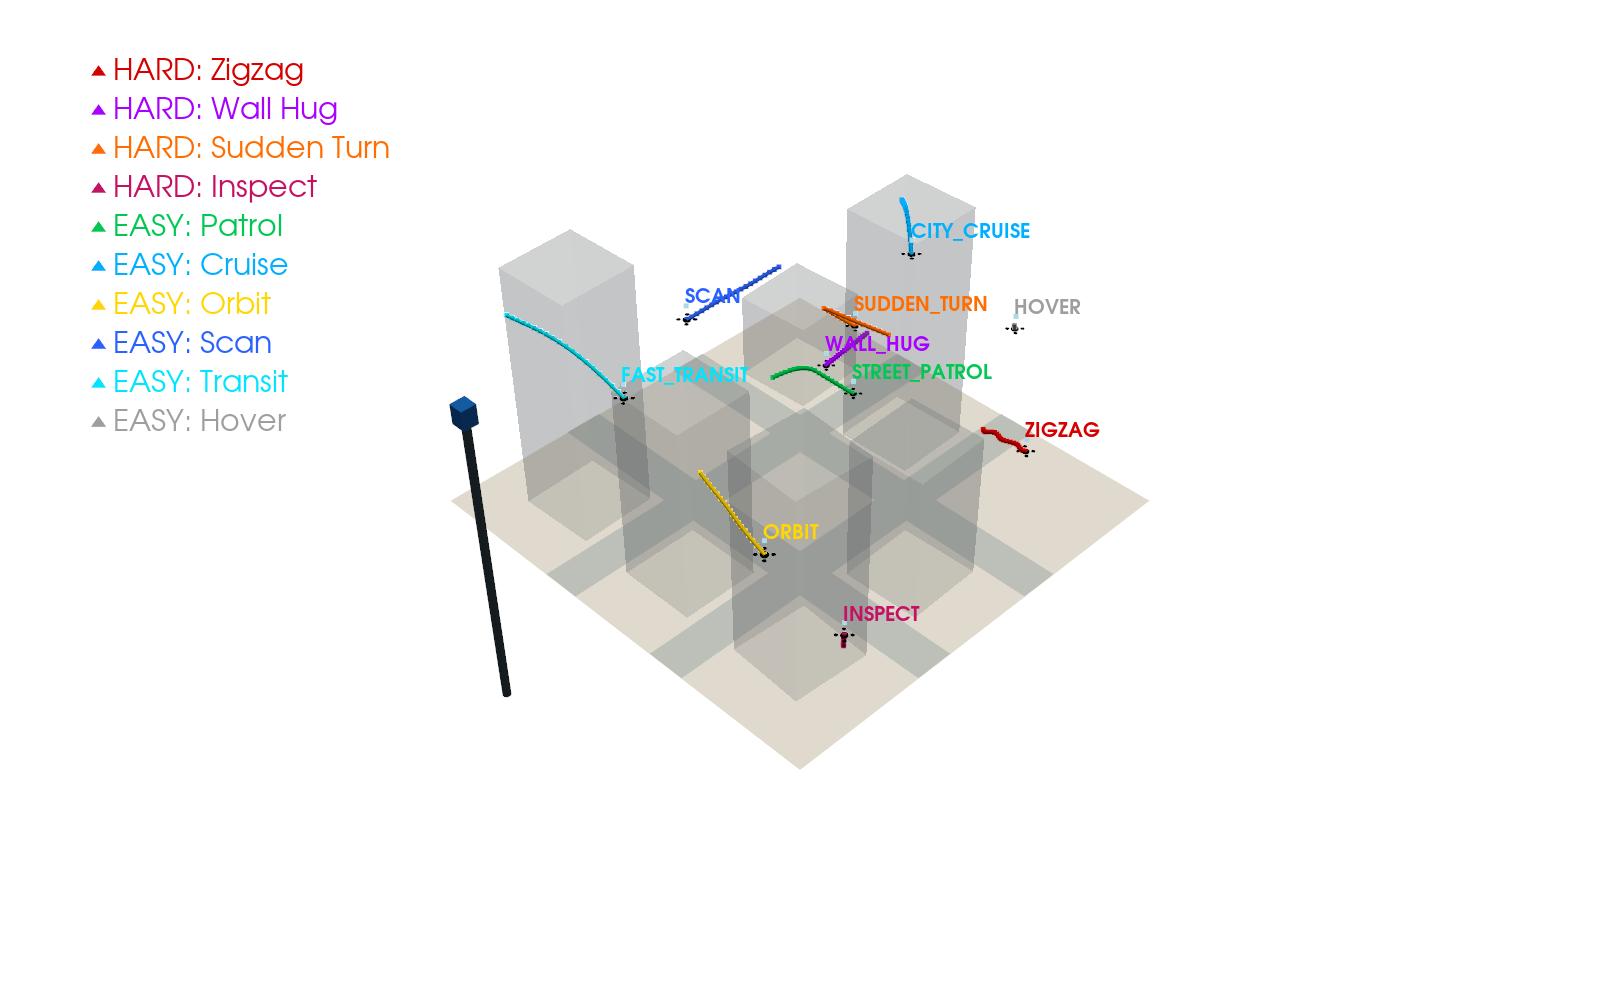

In [1]:
import pyvista as pv
import numpy as np
import pandas as pd
from pathlib import Path
import random
from collections import defaultdict

# ================= 📐 Visualization Colors & Modes =================

SCHEMATIC_CFG = {
    # --- Environment Colors ---
    "background": "#FFFFFF",
    "ground": "#F5F5F5",
    "road": "#CFD8DC", 
    "building": "#ECEFF1",
    "roof": "#B0BEC5",
    "bs_body": "#37474F",
    "bs_panel": "#1565C0",
    
    # --- 🔥 Hard Modes - Warm Colors 🔥 ---
    "Zigzag":      {"color": "#D50000", "label": "HARD: Zigzag"},
    "wall_hug":    {"color": "#AA00FF", "label": "HARD: Wall Hug"},
    "sudden_turn": {"color": "#FF6D00", "label": "HARD: Sudden Turn"},
    "inspect":     {"color": "#C51162", "label": "HARD: Inspect"},

    # --- 🍃 Easy Modes - Cool Colors 🍃 ---
    "street_patrol": {"color": "#00C853", "label": "EASY: Patrol"},
    "city_cruise":   {"color": "#00B0FF", "label": "EASY: Cruise"},
    "orbit":         {"color": "#FFD600", "label": "EASY: Orbit"},
    "scan":          {"color": "#2962FF", "label": "EASY: Scan"},
    "fast_transit":  {"color": "#00E5FF", "label": "EASY: Transit"},
    "hover":         {"color": "#9E9E9E", "label": "EASY: Hover"},
}

CITY_CONFIG = {
    "center_x": 75.0, 
    "bs_pos": [0.0, 0.0, 65.0]
}

DATASET_ROOT = Path("Dataset/OSM_Train_AllModes")

# ================= 🚁 Helper Functions =================
def create_uav_mesh(scale=1.0):
    """Create a simple black UAV mesh."""
    body = pv.Cylinder(center=(0,0,0), direction=(0,0,1), radius=0.5*scale, height=0.15*scale)
    rotors = []
    arm_len = 0.7 * scale
    offsets = [(arm_len, arm_len, 0), (arm_len, -arm_len, 0), (-arm_len, arm_len, 0), (-arm_len, -arm_len, 0)]
    for ox, oy, oz in offsets:
        rotors.append(pv.Disc(center=(ox, oy, 0.05*scale), outer=0.3*scale, inner=0))
    return body + rotors[0] + rotors[1] + rotors[2] + rotors[3]

def visualize_difficulty_contrast(city_idx=0):
    """
    Core visualization function: Contrast hard and easy trajectories (unified line style).
    """
    city_name = f"City_{city_idx + 1:03d}"
    city_dir = DATASET_ROOT / city_name
    static_mesh_dir = city_dir / "static_mesh"

    if not city_dir.exists():
        print(f"❌ City directory not found: {city_dir}")
        print(f"   Please check if your dataset path is: {DATASET_ROOT}")
        return

    # 1. Initialize Plotter
    p = pv.Plotter(window_size=(1600, 1000), title=f"Unified Trajectory Viz: {city_name}")
    p.set_background(SCHEMATIC_CFG["background"])
    uav_template = create_uav_mesh(scale=1.5)

    # 2. Load environment (translucent buildings to highlight trajectories)
    print("🏗️ Loading static environment...")
    if static_mesh_dir.exists():
        for ply in static_mesh_dir.glob("*.ply"):
            try:
                mesh = pv.read(ply)
                name = ply.name.lower()
                if "ground" in name: 
                    p.add_mesh(mesh.translate((0,0,-0.2)), color=SCHEMATIC_CFG["ground"])
                elif "road" in name: 
                    p.add_mesh(mesh.translate((0,0,-0.1)), color=SCHEMATIC_CFG["road"])
                elif "wall" in name: 
                    p.add_mesh(mesh, color=SCHEMATIC_CFG["building"], opacity=0.2)
                elif "roof" in name: 
                    p.add_mesh(mesh, color=SCHEMATIC_CFG["roof"], opacity=0.2)
            except: pass

    # 3. Draw Base Station (BS)
    bs_pos = np.array(CITY_CONFIG["bs_pos"])
    p.add_mesh(pv.Cylinder(center=(bs_pos[0], bs_pos[1], bs_pos[2]/2), direction=(0,0,1), radius=0.8, height=bs_pos[2]), 
               color=SCHEMATIC_CFG["bs_body"]) 
    p.add_mesh(pv.Box(bounds=(bs_pos[0]-1.5, bs_pos[0]+1.5, bs_pos[1]-1.5, bs_pos[1]+1.5, bs_pos[2]-2, bs_pos[2]+2)), 
               color=SCHEMATIC_CFG["bs_panel"])

    # 4. Filter trajectories: Select 1 for each mode
    print("🔍 Filtering trajectory samples...")
    all_csvs = list(city_dir.rglob("uav_trajectory.csv"))
    mode_map = defaultdict(list)
    for csv in all_csvs:
        try:
            mode = pd.read_csv(csv, nrows=1)['mode'].iloc[0]
            if mode in SCHEMATIC_CFG: mode_map[mode].append(csv)
        except: pass
    
    selected_files = []
    # Randomly select one, or skip if not enough
    for m in SCHEMATIC_CFG.keys():
        if mode_map[m]: 
            selected_files.append(random.choice(mode_map[m]))

    # 5. Draw trajectories (unified style)
    print("🎨 Drawing trajectories...")
    for csv_path in selected_files:
        df = pd.read_csv(csv_path)
        mode = df['mode'].iloc[0]
        pts = df[['x', 'y', 'z']].values
        
        cfg = SCHEMATIC_CFG[mode]
        color = cfg["color"]
        label = cfg["label"]
        
        # --- A. Unified Line Rendering ---
        # Create PolyData object
        line_mesh = pv.PolyData(pts)
        
        # Define line segment connectivity: [num_pts, p0, p1, p2, ...]
        # Continuous line: [N, 0, 1, ..., N-1]
        num_pts = len(pts)
        cells = np.hstack([[num_pts] + list(range(num_pts))])
        line_mesh.lines = cells
        
        # Use add_mesh to render lines
        # line_width controls thickness, render_lines_as_tubes adds 3D effect
        p.add_mesh(line_mesh, color=color, line_width=4, label=label, 
                   render_lines_as_tubes=True, opacity=1.0)

        # --- B. UAV Model and Start Point ---
        # Draw a UAV at the start point
        p.add_mesh(uav_template.copy().translate(pts[0]), color="black", smooth_shading=True)
        
        # Text label (above start point)
        p.add_point_labels([pts[0] + [0,0,3]], [mode.upper()], font_size=20, text_color=color, shape_opacity=0, always_visible=True)

    # 6. Display - Legend in upper left
    p.add_legend(bcolor='white', size=(0.2, 0.4), loc='upper left', face=None)
    
    # Set camera perspective
    p.camera_position = [(CITY_CONFIG["center_x"] - 200, -200, 250), (CITY_CONFIG["center_x"], 0, 0), (0, 0, 1)]
    
    print("\n✨ Unified line trajectory plot generated! Please check the window.")
    p.show()

if __name__ == "__main__":
    # Ensure city_idx is an actually generated city index (e.g., 0)
    visualize_difficulty_contrast(city_idx=0)

✅ Visualization complete: Single scalar bar (vertical).


/home/test/anaconda3/envs/sionna_gpu/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


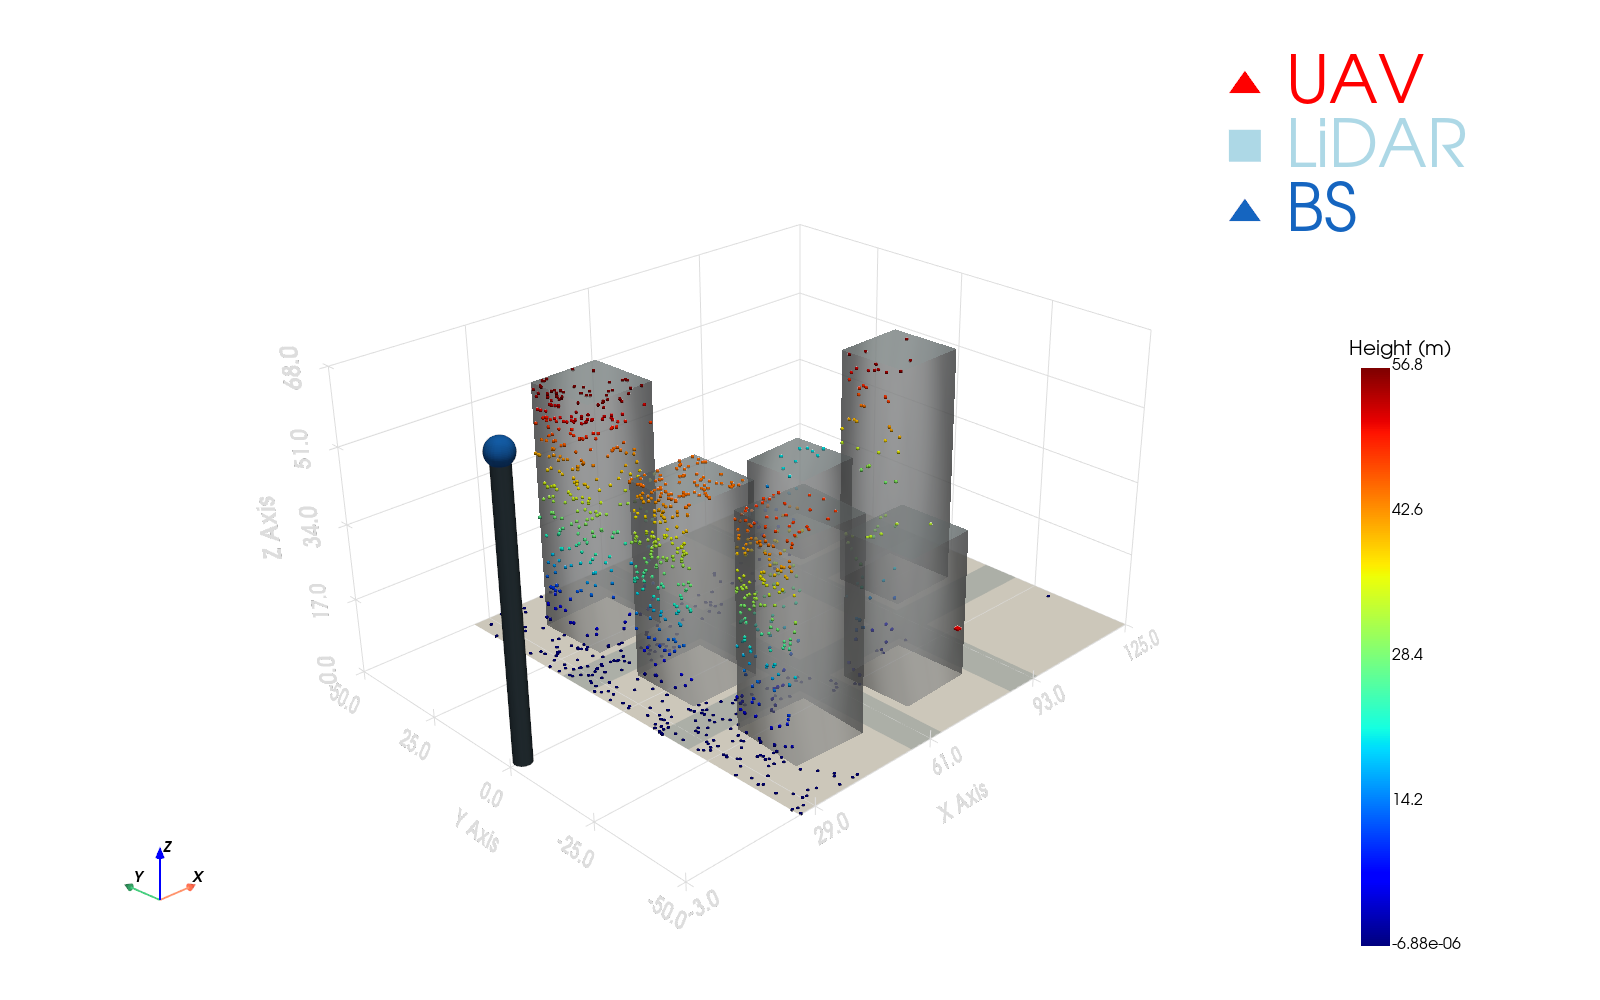

In [4]:
import pyvista as pv
import numpy as np
from pathlib import Path
import random

# ================= Configurations =================
DATASET_ROOT = Path("Dataset/OSM_Train_AllModes")
BS_POS = [0.0, 0.0, 65.0]  
TARGET_CITY_IDX = 0
CITY_CENTER = [75.0, 0.0, 30.0] 

def get_snapshot_in_city(root_dir, city_idx):
    if not root_dir.exists(): return None, None
    city_name = f"City_{city_idx + 1:03d}"
    city_dir = root_dir / city_name
    if not city_dir.exists(): return None, None
    
    trajs = list(city_dir.glob("Traj_*"))
    if not trajs: return city_dir, None
    traj = random.choice(trajs)
    
    times = list((traj / "times").glob("time_*"))
    if not times: return city_dir, None
    time_folder = random.choice(times)
    return city_dir, time_folder

def visualize_wide_view_fixed():
    city_dir, time_dir = get_snapshot_in_city(DATASET_ROOT, TARGET_CITY_IDX)
    if not city_dir: return

    title_str = f"Wide View: {city_dir.name}"
    if time_dir: title_str += f" | {time_dir.parent.parent.name}"
    
    p = pv.Plotter(window_size=(1600, 1000), title=title_str)
    p.set_background("white")

    # --- 1. Static Environment ---
    static_dir = city_dir / "static_mesh"
    if static_dir.exists():
        if (f := static_dir / "ground_base.ply").exists():
            p.add_mesh(pv.read(f), color="#F5F5F5")
        for f in static_dir.glob("road_*.ply"):
            p.add_mesh(pv.read(f), color="#CFD8DC")
        for f in static_dir.glob("bld_*_wall.ply"):
            p.add_mesh(pv.read(f), color="#ECEFF1", opacity=0.6, smooth_shading=True)
        for f in static_dir.glob("bld_*_roof.ply"):
            p.add_mesh(pv.read(f), color="#90A4AE", opacity=0.6, smooth_shading=True)

    # --- 2. Dynamic Objects ---
    if time_dir:
        uav_ply = time_dir / "mesh" / "uav.ply"
        if uav_ply.exists():
            mesh = pv.read(uav_ply)
            p.add_mesh(mesh, color="red", point_size=10, render_points_as_spheres=True, label="UAV")
            # p.add_lines(np.array([BS_POS, mesh.center]), color="orange", width=3, label="LoS Ray")

        lidar_files = list(time_dir.glob("bs_lidar_*.ply"))
        if lidar_files:
            cloud = pv.read(lidar_files[0])
            if cloud.n_points > 0:
                # ---------------- 👇 Key Modification Here 👇 ----------------
                p.add_mesh(cloud, 
                           scalars=cloud.points[:, 2], 
                           cmap="jet", 
                           point_size=4.0, 
                           render_points_as_spheres=True, 
                           label="LiDAR",
                           # 1. Enable color bar
                           show_scalar_bar=True, 
                           # 2. Detailed color bar configuration (vertical, position, font)
                           scalar_bar_args={
                               "title": "Height (m)",
                               "vertical": True,       # Key: Set to vertical
                               "title_font_size": 20,
                               "label_font_size": 16,
                               "color": "black",       # Font color
                               "position_x": 0.85,     # Right aligned (0-1)
                               "position_y": 0.05,     # Bottom aligned (0-1)
                               "height": 0.6,          # Length
                               "width": 0.05           # Width
                           })
                # -----------------------------------------------------

    # --- 3. Base Station ---
    p.add_mesh(pv.Cylinder(center=(BS_POS[0], BS_POS[1], BS_POS[2]/2), direction=(0,0,1), radius=2.0, height=BS_POS[2]), color="#37474F")
    p.add_mesh(pv.Sphere(radius=3.0, center=BS_POS), color="#1565C0", label="BS")

    # --- 4. Camera View ---
    p.add_legend(bcolor='white', size=(0.2, 0.2)) # Top-left legend (UAV, BS, etc.)
    p.show_grid(color="#DDDDDD")
    p.show_axes()

    cam_pos = [CITY_CENTER[0] - 250, CITY_CENTER[1] - 250, 200]
    p.camera_position = [cam_pos, CITY_CENTER, [0, 0, 1]]
    
    print(f"✅ Visualization complete: Single scalar bar (vertical).")
    p.show()

if __name__ == "__main__":
    visualize_wide_view_fixed()